In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [20]:
df = pd.DataFrame({
    "Experience" : [1,2,3,4,5],
    "Salary" : [20000,25000,32000,42000,55000]
})
X = df[["Experience"]]
y = df["Salary"]

linear_model = LinearRegression()
linear_model.fit(X,y)
#y = 8700 + 8700x
linear_predict = linear_model.predict(X)


poly = PolynomialFeatures(
    degree = 2,
    include_bias = False
)
X_poly= poly.fit_transform(X)
X_poly
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
#y=1.8200 + 557.14x = 1357.14x^2

poly_predict = poly_model.predict(X_poly)
poly_predict

comparison = pd.DataFrame({
    "Experience" : df["Experience"],
    "Actual Salary" : y,
    "Linear Prediction" : linear_predict,
    "Polynomial Prediction" : poly_predict
})
comparison

,Experience,Actual Salary,Linear Prediction,Polynomial Prediction
0,1,20000,17400.0,20114.285714
1,2,25000,26100.0,24742.857143
2,3,32000,34800.0,32085.714286
3,4,42000,43500.0,42142.857143
4,5,55000,52200.0,54914.285714


In [3]:
df = pd.read_csv("datasets/student_marks.csv")

In [4]:
df

,Student,StudyHours,FinalMarks
0,Aarav,1.0,28
1,Aayush,2.0,35
2,Sita,2.5,40
3,Ram,3.0,45
4,Anisha,3.5,50
5,Rohan,4.0,55
6,Priya,4.5,60
7,Kiran,5.0,65
8,Nabin,5.5,70
9,Suman,6.0,74


In [5]:
df.head()

,Student,StudyHours,FinalMarks
0,Aarav,1.0,28
1,Aayush,2.0,35
2,Sita,2.5,40
3,Ram,3.0,45
4,Anisha,3.5,50


In [6]:
df.shape

(15, 3)

In [7]:
type(df)

pandas.DataFrame

In [8]:
df.isna().sum()

Student       0
StudyHours    0
FinalMarks    0
dtype: int64

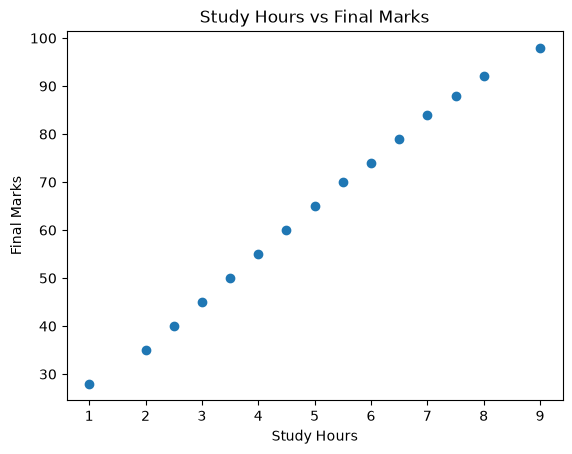

In [9]:
X = df[['StudyHours']]
y = df.FinalMarks
plt.scatter(X,y)
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")
X = X.to_numpy()
y = y.to_numpy()


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state =42
)
X_train

array([[8. ],
       [4. ],
       [5.5],
       [2.5],
       [2. ],
       [9. ],
       [3.5],
       [5. ],
       [6.5],
       [7.5],
       [3. ],
       [4.5]])

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9.25]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.74
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[7.51]


In [18]:
# Print the raw parameters
print(f"Intercept (Bias): {model.intercept_}")
print(f"Coefficient (Weight): {model.coef_[0]}")


Intercept (Bias): 17.738552437223056
Coefficient (Weight): 9.24815361890694


In [19]:
predicted_y = model.predict(X_test)
predicted_y

array([73.22747415, 82.47562777, 26.98670606])

In [20]:
comparison = pd.DataFrame({
    "Acutal" : y_test,
    "Predicted" : predicted_y
})
comparison

,Acutal,Predicted
0,74,73.227474
1,84,82.475628
2,28,26.986706


In [43]:
new_students = np.array([
    [2], 
    [4], 
    [6], 
    [8], 
    [2] ])
marks_prediction = model.predict(new_students)
marks_prediction

array([ 36.23485968,  54.73116691,  73.22747415,  91.72378139,
       110.22008863])